In [1]:
import numpy as np
import matplotlib.pyplot as plt

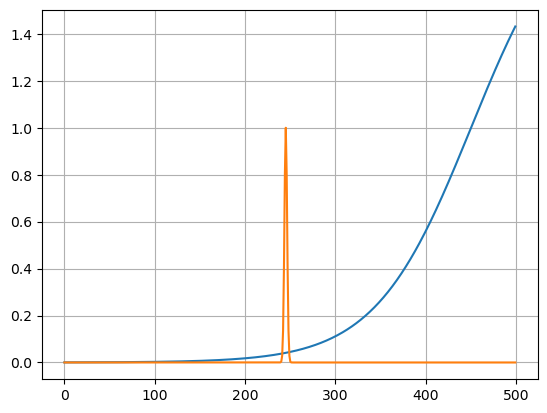

surface gravity :  0.006527049196878705
1.0
0.0


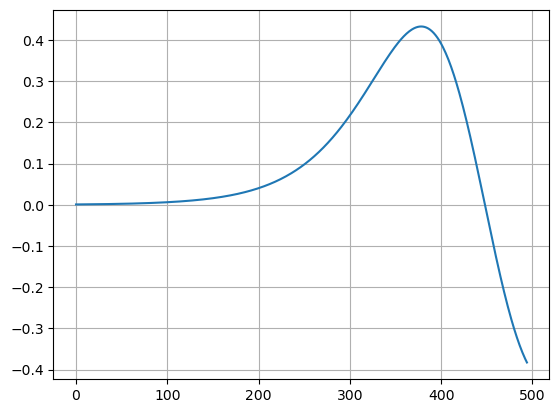

0.1047579346505086
5.4789375878605995


In [18]:
#case 3
def beta(j,L,epsilon):
    width = 0.75
    A = 1
    jh = int(L*0.9)
    return  A*np.tanh(width*(j - jh)*epsilon) + A

L = 500
l = 2*np.pi
epsilon = l / L
bs = [beta(j,L,epsilon) for j in range(L)]
plt.plot([j for j in range(L)], bs)
j0 = 245
sigma = 0.003*L
weights = np.exp(-((np.arange(L) - j0) ** 2) / (2 * sigma ** 2))
plt.plot([j for j in range(L)], weights)
plt.grid()
plt.show()
print("surface gravity : ", (bs[126]-bs[124])/(2*epsilon))
print(bs[450])
print(weights[450])
bs_diff_diff = [((bs[j+2]-bs[j])/(2*epsilon) - (bs[j]-bs[j-2])/(2*epsilon))/(2*epsilon) for j in range(2,L-3)]
plt.plot(bs_diff_diff)
plt.grid()
plt.show()
print(bs_diff_diff[438])
print(436*epsilon)

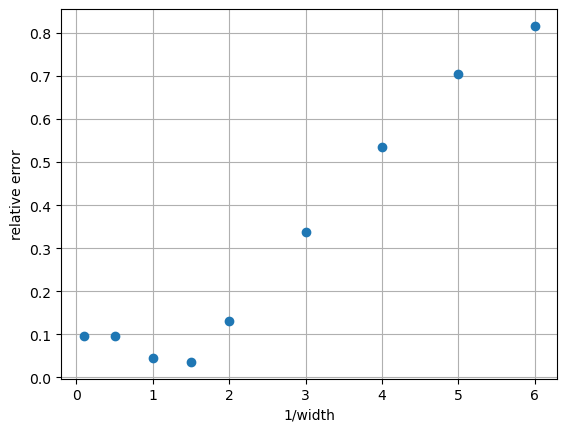

In [41]:
width = [0.1,0.5,1,1.5,2,3,4,5,6]
sg_from_beta = np.array([0.0999999,0.49999,0.99999,1.5,1.999,2.999,4,5,5.999])
sg_from_sigma = np.array([0.1096,0.5482,1.044,1.446,1.738,1.985,1.862,1.481,1.103])
plt.plot(width,abs((sg_from_beta - sg_from_sigma)/sg_from_beta),"o")
plt.xlabel("1/width")
plt.ylabel("relative error")
plt.grid()
plt.show()

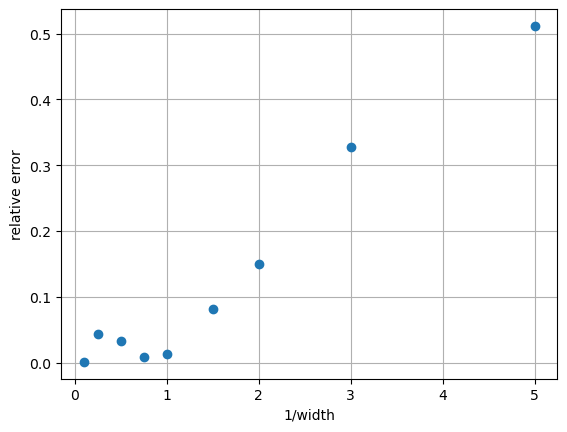

In [39]:
width = [0.1,0.25,0.5,0.75,1,1.5,2,3,5]
sg_from_beta = np.array([0.0999999,0.25,0.49999,0.75,1,1.5,2,3,5])
sg_from_sigma = np.array([0.1001,0.2608,0.5165,0.7559,0.9862,1.377,1.699,2.019,2.441])
plt.plot(width,abs(sg_from_beta - sg_from_sigma)/sg_from_beta,"o")
plt.xlabel("1/width")
plt.ylabel("relative error")
plt.grid()
plt.show()

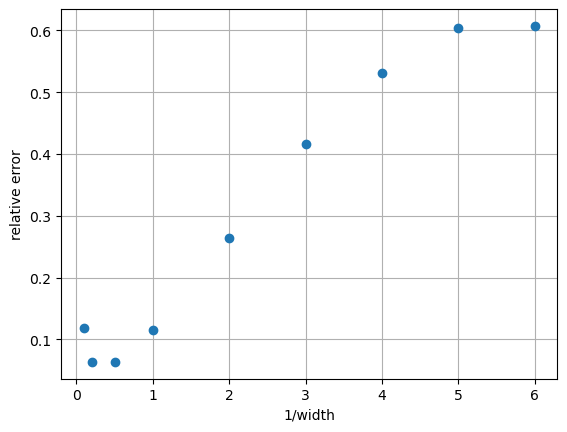

In [4]:
width = [0.1,0.2,0.5,1,2,3,4,5,6]
sg_from_beta = np.array([0.1,0.2,0.5,1,2,3,4,5,6])
sg_from_sigma = np.array([0.08824,0.1873,0.4681,0.885,1.471,1.75,1.878,1.979,2.356])
plt.plot(width,abs((sg_from_beta - sg_from_sigma)/sg_from_beta),"o")
plt.xlabel("1/width")
plt.ylabel("relative error")
plt.grid()
plt.show()

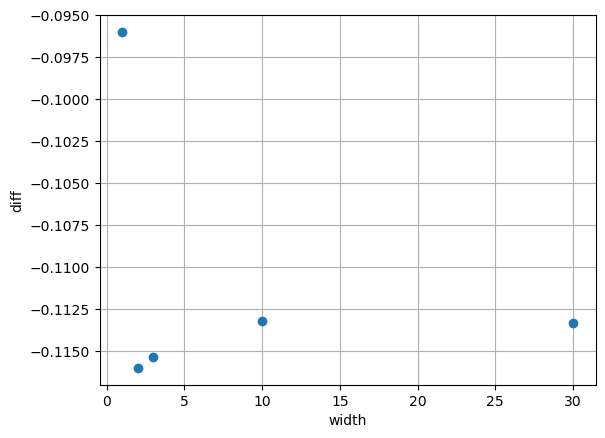

In [9]:
width = [1,2,3,10,30]
sg_from_beta = np.array([0.1,0.2,0.3,1,3])
sg_from_sigma = np.array([0.1096,0.2232,0.3346,1.1132,3.340])
plt.plot(width,(sg_from_beta - sg_from_sigma)/sg_from_beta,"o")
plt.xlabel("width")
plt.ylabel("diff")
plt.grid()
plt.show()

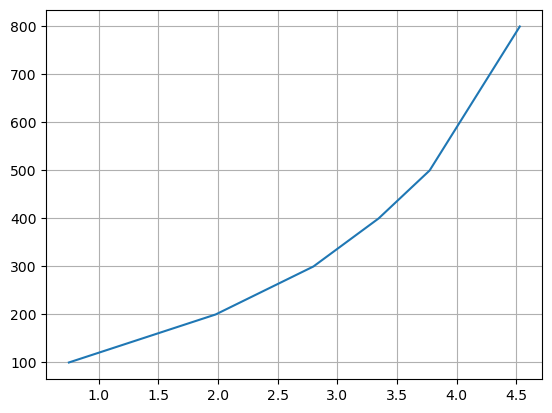

In [5]:
import numpy as np
import matplotlib.pyplot as plt
L=[100,200,300,400,500,800]
T0=[5.16,4.38,4.06,3.877,3.756,3.551]
Tf=[5.91,6.36,6.86,7.223,7.53,8.081]
plt.plot(np.array(Tf)-np.array(T0),L)
plt.grid()
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===== データ =====
Tf = np.array([5.91, 6.36, 6.86, 7.223, 7.53, 7.95,8.081])
T0 = np.array([5.16, 4.38, 4.06, 3.877, 3.756, 3.551])
Tf = np.array([5.91, 6.36, 6.86, 7.223, 7.53, 8.081])

x = Tf - T0   # 横軸
y = L         # 縦軸

# ===== 指数関数モデル =====
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

# --- b を自由にしたフィット ---
params_free, _ = curve_fit(exp_func, x, y, p0=(50, 0.5, 0))
a_free, b_free, c_free = params_free

# --- b = 0.75 固定フィット ---
def exp_fixed_b(x, a, c):
    return a * np.exp(0.75 * x) + c

params_fixed, _ = curve_fit(exp_fixed_b, x, y, p0=(50, 0))
a_fixed, c_fixed = params_fixed

# ===== 描画 =====
x_plot = np.linspace(min(x)*0.9, max(x)*1.1, 300)

plt.figure()
plt.scatter(x, y)

plt.plot(
    x_plot,
    exp_fixed_b(x_plot, a_fixed, c_fixed),
    linestyle="-",
    color = "red",
    label="Theoretical prediction",
)
plt.plot(np.array(Tf)-np.array(T0),L,"o",label="Numerical simulation",color="blue")
plt.xlabel("T",fontsize=25,fontweight="bold")
plt.ylabel("L",fontsize=25,fontweight="bold")
plt.legend(fontsize=17)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid()
plt.show()

# ===== パラメータ表示 =====
print("free fit:")
print(f"a = {a_free:.3f}, b = {b_free:.3f}, c = {c_free:.3f}")

print("\nb = 0.75 fixed:")
print(f"a = {a_fixed:.3f}, c = {c_fixed:.3f}")


ValueError: operands could not be broadcast together with shapes (6,) (7,) 

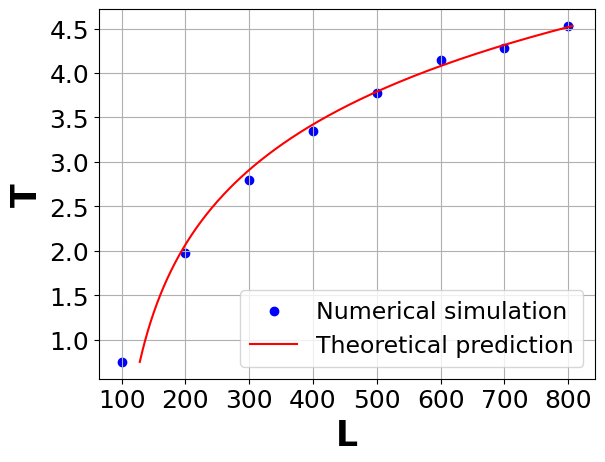

free fit:
a = 42.481, b = 0.634, c = 41.279

b = 0.75 fixed:
a = 24.104, c = 86.229


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===== データ =====
L = np.array([100, 200, 300, 400, 500,600,700, 800], dtype=float)
T0 = np.array([5.16, 4.38, 4.06, 3.877, 3.756,3.60,3.67,3.551])
Tf = np.array([5.91, 6.36, 6.86, 7.223, 7.53,7.75,7.95, 8.081])

x = Tf - T0   # 元の横軸
y = L         # 元の縦軸

# ===== 指数関数モデル =====
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

# --- b を自由にしたフィット ---
params_free, _ = curve_fit(exp_func, x, y, p0=(50, 0.5, 0))
a_free, b_free, c_free = params_free

# --- b = 0.75 固定フィット ---
def exp_fixed_b(x, a, c):
    return a * np.exp(0.75 * x) + c

params_fixed, _ = curve_fit(exp_fixed_b, x, y, p0=(50, 0))
a_fixed, c_fixed = params_fixed

# ===== 描画（ここだけ反転）=====
x_plot = np.linspace(min(x)*1, max(x)*1, 300)

plt.figure()

# ★ scatter を反転
plt.scatter(y, x, color="blue", label="Numerical simulation")

# ★ 理論曲線も反転
plt.plot(
    exp_fixed_b(x_plot, a_fixed, c_fixed),
    x_plot,
    linestyle="-",
    color="red",
    label="Theoretical prediction",
)

plt.xlabel("L", fontsize=25, fontweight="bold")
plt.ylabel("T", fontsize=25, fontweight="bold")
plt.legend(fontsize=17)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid()
plt.show()

# ===== パラメータ表示 =====
print("free fit:")
print(f"a = {a_free:.3f}, b = {b_free:.3f}, c = {c_free:.3f}")

print("\nb = 0.75 fixed:")
print(f"a = {a_fixed:.3f}, c = {c_fixed:.3f}")
